# **DogeSkin**



## **Classification Algorithms**

1. **Logistic Regression**

2. **k-NN**

3. **Decision Tree**

4. **Random Forest**

5. **SVM**

6. **MLP**

## **Evaluation Metrices**

1. **Accuracy**

2. **Precision**

3. **Recall**

4. **F1-Score**

5. **Confusion Matrix**

## **Experiments**

1. **Traditional ML using Raw Pixels:** Where the images are resized to 64x64 pixels, transformed into grayscale, flattened then the algorithms are used, and finally evaluated.

2. **Traditional ML using MobileNetV2 Features:** Where the images are resized to 224x224 by saving their RGB features, then the MobileNetV2 feature extractor is used, then the algorithms are use, and finally evaluated.

3. **Transfer Learning with Epochs:** Where the images are 
Dog image
-> MobileNetV2 / EfficientNetB0
-> custom dense layers
-> train with epochs
-> validation monitoring
-> test evaluation

## **Dataset**

1. **Dog's Skin Diseases (Image Dataset)**: [kaggle](https://www.kaggle.com/datasets/youssefmohmmed/dogs-skin-diseases-image-dataset/data)



## **A. Default Actions**

### **A.1. Importing Required Libraries**

In [65]:
from pathlib import Path
from collections import Counter, defaultdict
import hashlib
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image, UnidentifiedImageError

### **A.2. Shutting Down Unwanted Warnings**

In [66]:
import warnings

warnings.filterwarnings('ignore')

## **B. Loading Datasets**

### **B.1. Importing Datasets from Local Library**

In [67]:
DATASETS_PATH = Path('../datasets/feed')

TRAINING_SETS = DATASETS_PATH / 'train'
VALIDATION_SETS = DATASETS_PATH / 'valid'
TEST_SETS = DATASETS_PATH / 'test'

print(f'Path <{DATASETS_PATH}> Exists?', DATASETS_PATH.exists())
print(f'Path <{TRAINING_SETS}> Exists?', TRAINING_SETS.exists())
print(f'Path <{VALIDATION_SETS}> Exists?', VALIDATION_SETS.exists())
print(f'Path <{TEST_SETS}> Exists?', TEST_SETS.exists())

Path <../datasets/feed> Exists? True
Path <../datasets/feed/train> Exists? True
Path <../datasets/feed/valid> Exists? True
Path <../datasets/feed/test> Exists? True


### **B.2. Extracting Label Information**

In [68]:
labels = sorted([file.name for file in TRAINING_SETS.iterdir() if file.is_dir()])
print(len(labels), 'labels :',labels)

6 labels : ['Demodicosis', 'Dermatitis', 'Fungal Infections', 'Healthy', 'Hypersensitivity', 'Ringworm']


### **B.3. Image Dataset to Dataframe**

In [69]:
extensions = {'.jpg', '.jpeg' '.png', '.bmp', '.webp'}

records = []

for split, path in [
    ('train', TRAINING_SETS),
    ('valid', VALIDATION_SETS),
    ('test', TEST_SETS)
]:
    if path.exists():
        for file in path.iterdir():
            if file.is_dir():
                label = file.name
                
                for img in file.rglob('*'):
                    if img.suffix.lower() in extensions:
                        records.append({
                            'split': split,
                            'label': label,
                            'path': str(img),
                        })

df_images = pd.DataFrame(records)

print("Total Images:", len(df_images))
print(f'Total: {len(df_images)} | Splits: {df_images['split'].nunique()} | Labels: {df_images['label'].nunique()}')

df_images.sample(10)

Total Images: 4315
Total: 4315 | Splits: 3 | Labels: 6


,split,label,path
3870,valid,Dermatitis,../datasets/feed/valid/Dermatitis/HOT-SPOT-IN-...
2108,train,Demodicosis,../datasets/feed/train/Demodicosis/2024-05-13-...
1363,train,Ringworm,../datasets/feed/train/Ringworm/5A4BF21E-2505-...
1067,train,Ringworm,../datasets/feed/train/Ringworm/R3_png_jpg.rf....
3285,valid,Ringworm,../datasets/feed/valid/Ringworm/ringworm-41-_j...
2106,train,Demodicosis,../datasets/feed/train/Demodicosis/scabies_128...
3827,valid,Dermatitis,../datasets/feed/valid/Dermatitis/1000010781_x...
2651,train,Dermatitis,../datasets/feed/train/Dermatitis/hotspot-68-_...
3704,valid,Hypersensitivity,../datasets/feed/valid/Hypersensitivity/Hypers...
937,train,Ringworm,../datasets/feed/train/Ringworm/R8_png_jpg.rf....


#### **B.3.1. Label Count & Chart**

In [70]:
label_counts = (
    df_images
    .groupby(['split', 'label'])
    .size()
    .reset_index(name='count')
)

label_counts

,split,label,count
0,test,Demodicosis,100
1,test,Dermatitis,66
2,test,Fungal Infections,54
3,test,Healthy,69
4,test,Hypersensitivity,29
5,test,Ringworm,115
6,train,Demodicosis,588
7,train,Dermatitis,546
8,train,Fungal Infections,375
9,train,Healthy,492


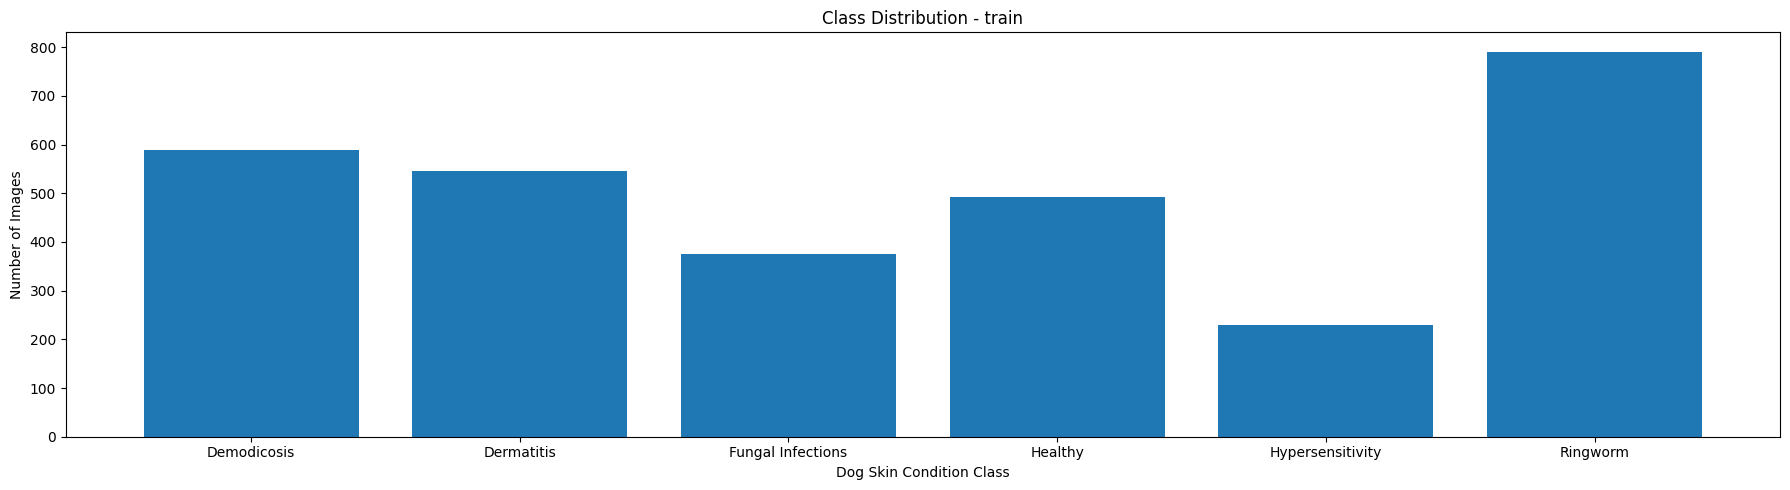

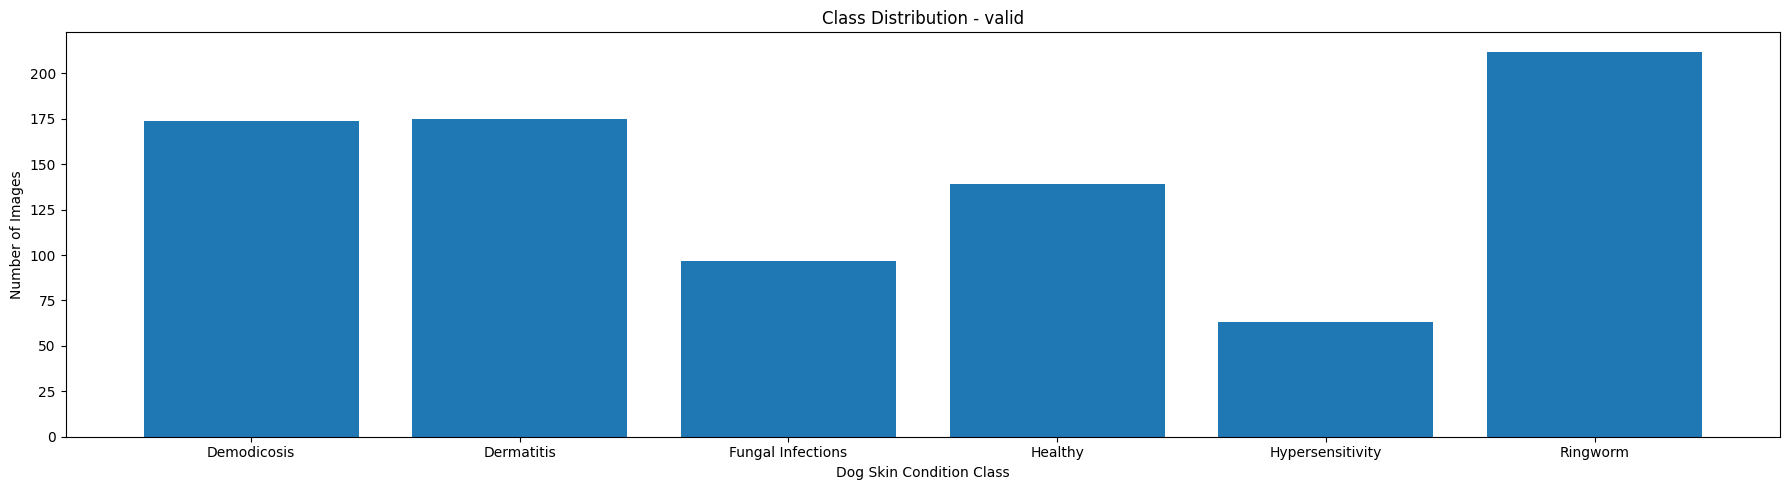

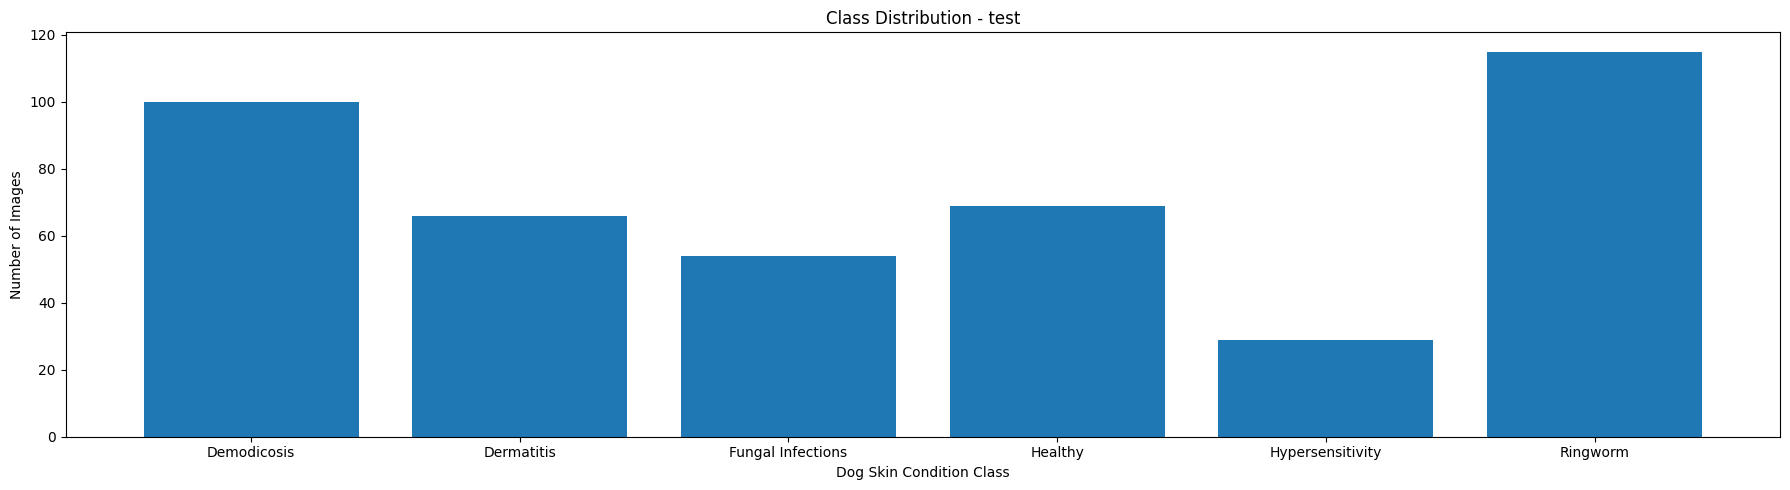

In [71]:
for split in df_images['split'].unique():
    
    split_counts = label_counts[label_counts['split'] == split]
    
    plt.figure(figsize=(18, 5))
    plt.bar(split_counts['label'], split_counts['count'])
    plt.title(f"Class Distribution - {split}")
    plt.xlabel("Dog Skin Condition Class")
    plt.ylabel("Number of Images")
    plt.tight_layout()
    plt.show()

## **C. Cleaning Data**

### **C.1. Checking for Corrupted Files**

In [72]:
images = []
corruped = []

for _, row in df_images.iterrows():
    path = Path(row['path'])
    
    try:
        with Image.open(path) as img:
            width, height = img.size
            mode = img.mode
            
        images.append({
            'split': split,
            'label': label,
            'path': str(img),
            'width': width,
            'height': height,
            'mode': mode
        })
        
    except(UnidentifiedImageError, OSError):
        corruped.append(row['path'])
        
df_info = pd.DataFrame(images)

print("Readable Images: ", len(df_info))
print("Corrupted Files: ", len(corruped))

if corruped:
    print("Corrupted Images: ")
    for img in corruped[:10]:
        print(img)
    
else:
    print("\nSince, there were no corrupted files, proceeding with the original dataframe.")

Readable Images:  4315
Corrupted Files:  0

Since, there were no corrupted files, proceeding with the original dataframe.


### **C.2. Checking for Duplicates**

#### **C.2.1 Overall Duplicates**

In [73]:
def get_file_hash(path):
    with open(path, 'rb') as file:
        return hashlib.md5(file.read()).hexdigest()
    
file_hashes = []

for _, row in df_images.iterrows():
    
    path = Path(row['path'])
    
    try:
        file_hash = get_file_hash(path)
        file_hashes.append({
            'split': row['split'],
            'label': row['label'],
            'path': row['path'],
            'file_hash': file_hash,
        })
        
    except(OSError):
        ...
        
df_hashes = pd.DataFrame(file_hashes)

total = len(df_hashes)
unique = df_hashes['file_hash'].nunique()
duplicates = total - unique

# duplicate_group_count = (
#     df_hashes.groupby('file_hash')
#     .size()
#     .gt(1)
#     .sum()
# )

# files_in_duplicate_groups = (
#     df_hashes.groupby('file_hash')
#     .filter(lambda x: len(x) > 1)
#     .shape[0]
# )

print("Total Images:", total)
print(f"Unique Images:", unique)
print("Dupluplicate Images:", duplicates)

Total Images: 4315
Unique Images: 4233
Dupluplicate Images: 82


#### **C.2.2. Duplicates Within Splits**

In [74]:
split_hashes = {}

for split in df_hashes["split"].unique():
    split_hashes[split] = set(
        df_hashes[df_hashes["split"] == split]["file_hash"]
    )

for split_a in split_hashes:
    for split_b in split_hashes:
        if split_a < split_b:
            overlap = split_hashes[split_a].intersection(split_hashes[split_b])
            print(f"{split_a} vs {split_b} duplicate overlap:", len(overlap))

train vs valid duplicate overlap: 21
test vs train duplicate overlap: 7
test vs valid duplicate overlap: 2


#### **C.2.3. Removing Duplicates**

In [75]:
split_priority = {
    'test': 0,
    'valid': 1,
    'train': 2
}

df_hashes['split_priority'] = df_hashes['split'].map(split_priority)

df_clean = (
    df_hashes
    .sort_values(by=['file_hash', 'split_priority'])
    .drop_duplicates(subset='file_hash', keep='first')
    .drop(columns=['split_priority'])
    .reset_index(drop=True)
)

print("Original Image Files:", len(df_hashes))
print("Unique Images:", len(df_clean))
print("Diplicates Removed:", len(df_hashes) - len(df_clean))

print("\nClean class distribution:")
print(df_clean.groupby(['split', 'label']).size())

Original Image Files: 4315
Unique Images: 4233
Diplicates Removed: 82

Clean class distribution:
split  label            
test   Demodicosis          100
       Dermatitis            66
       Fungal Infections     54
       Healthy               69
       Hypersensitivity      29
       Ringworm             115
train  Demodicosis          588
       Dermatitis           544
       Fungal Infections    336
       Healthy              492
       Hypersensitivity     195
       Ringworm             791
valid  Demodicosis          174
       Dermatitis           175
       Fungal Infections     94
       Healthy              139
       Hypersensitivity      60
       Ringworm             212
dtype: int64


#### **C.2.4. Checking Within Folders**

In [76]:
split_hashes_clean = {}

for split in df_clean['split'].unique():
    split_hashes_clean[split] = set(
        df_clean[df_clean['split'] == split]['file_hash']
    )
    
for split_a in split_hashes_clean:
    for split_b in split_hashes_clean:
        if split_a < split_b:
            overlap = split_hashes_clean[split_a].intersection(split_hashes_clean[split_b])
            print(f"{split_a} vs {split_b} duplicate overlap after cleaning:", len(overlap))

train vs valid duplicate overlap after cleaning: 0
test vs train duplicate overlap after cleaning: 0
test vs valid duplicate overlap after cleaning: 0


#### **C.2.5. Updated Dataset**

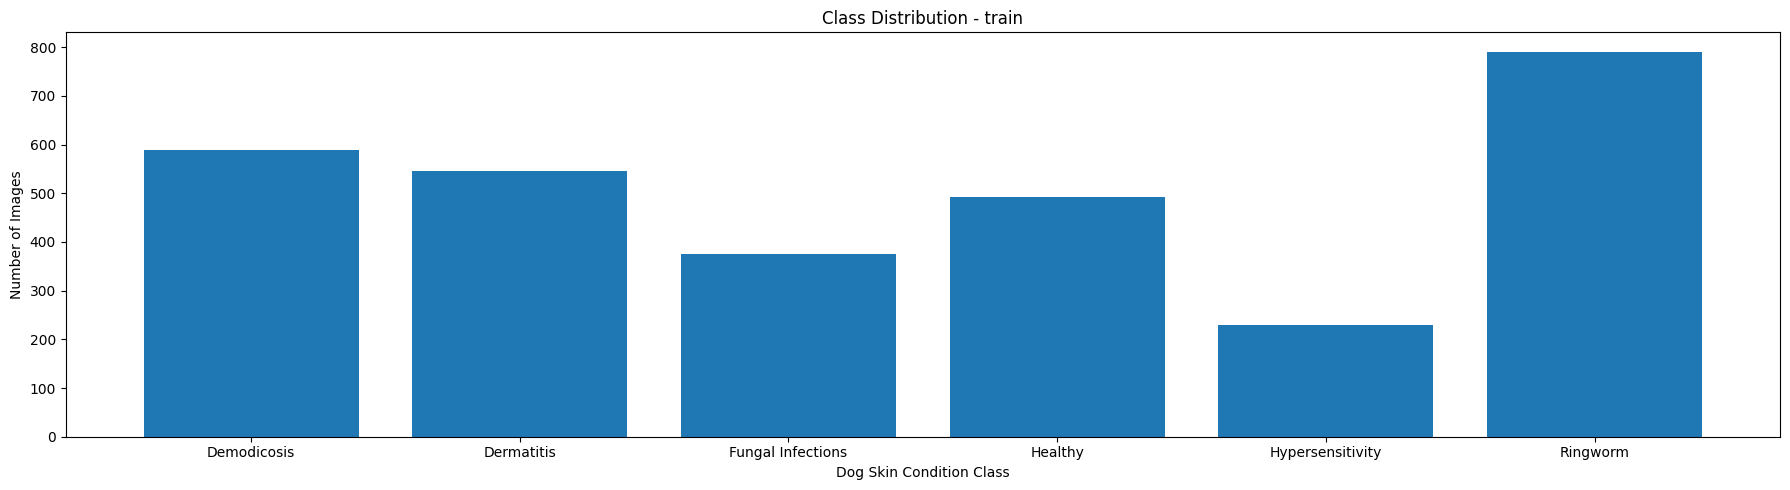

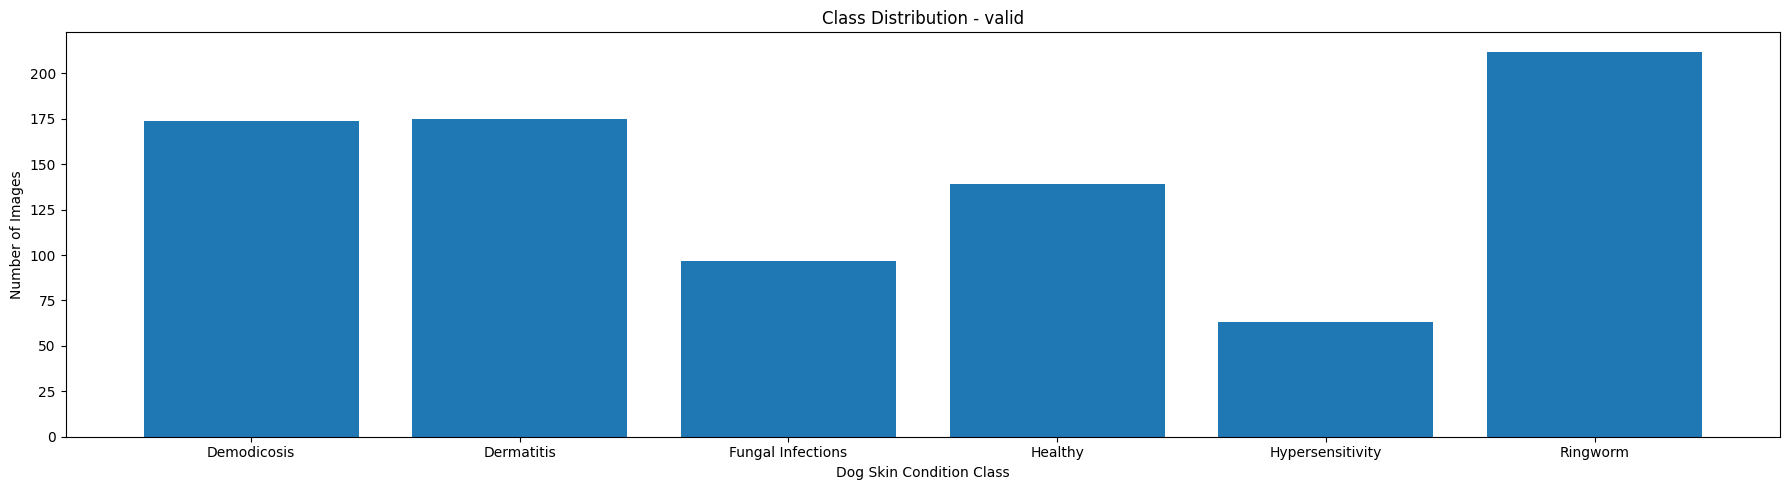

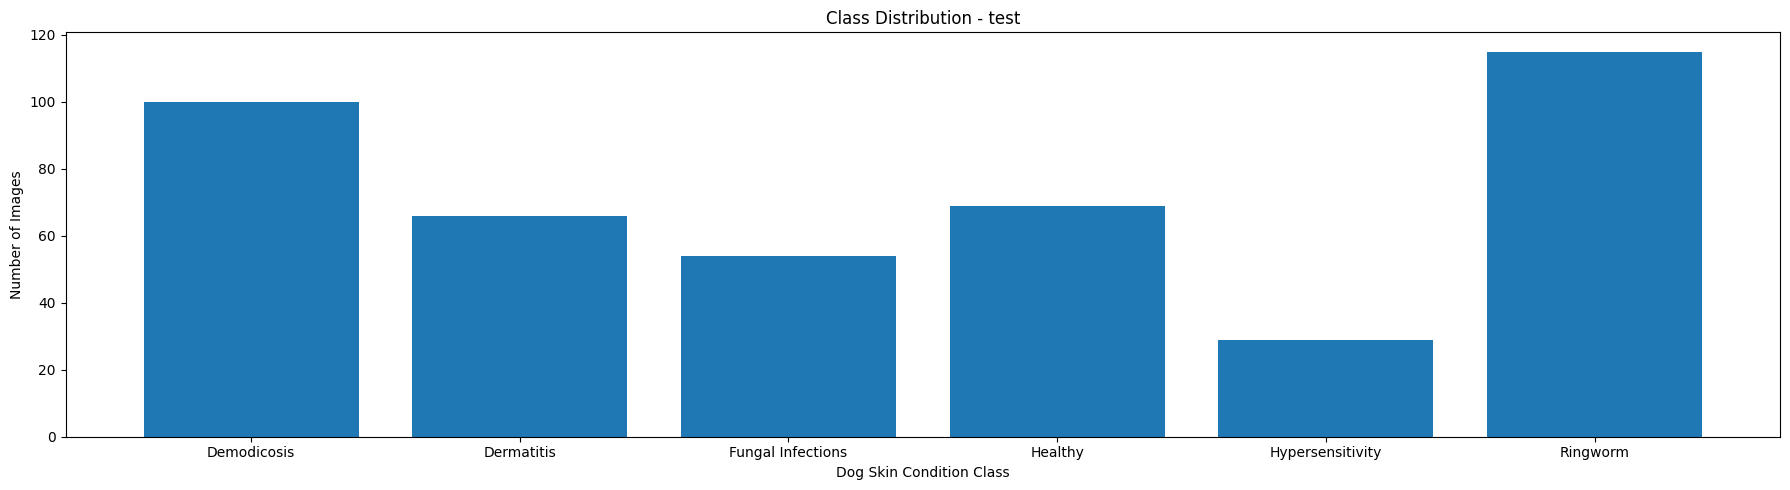

In [77]:
for split in df_clean['split'].unique():
    
    split_counts = label_counts[label_counts['split'] == split]
    
    plt.figure(figsize=(18, 5))
    plt.bar(split_counts['label'], split_counts['count'])
    plt.title(f"Class Distribution - {split}")
    plt.xlabel("Dog Skin Condition Class")
    plt.ylabel("Number of Images")
    # plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

## **D. Training & Testing**

### **D.1. Training Split (train + valid labels) & Testing Split (test label)**

In [ ]:
# Separating training (train + valid) and test sets.

df_train = df_clean[df_clean["split"].isin(["train", "valid"])].reset_index(drop=True)
df_test = df_clean[df_clean['split'] == 'test'].reset_index(drop=True)

# print(df_train.head(5))
# print(df_test.head(5))

print("Training Images:", len(df_train))
print("Testing Images:", len(df_test))

print("\nTraining Info:")
print(df_train['label'].value_counts().sort_index())

print("\nTesting Info:")
print(df_test['label'].value_counts().sort_index())

Training Images: 3800
Testing Images: 433

Training Info:
label
Demodicosis           762
Dermatitis            719
Fungal Infections     430
Healthy               631
Hypersensitivity      255
Ringworm             1003
Name: count, dtype: int64

Testing Info:
label
Demodicosis          100
Dermatitis            66
Fungal Infections     54
Healthy               69
Hypersensitivity      29
Ringworm             115
Name: count, dtype: int64


### **D.2. Encoding Labels**

In [79]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

df_train['e_label'] = label_encoder.fit_transform(df_train['label'])
df_test['e_label'] = label_encoder.fit_transform(df_test['label'])

print("Label Mapping:")

for label, e_label in zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)):
    print(f'{label}: {e_label}')

Label Mapping:
Demodicosis: 0
Dermatitis: 1
Fungal Infections: 2
Healthy: 3
Hypersensitivity: 4
Ringworm: 5


### **D.3. Raw Pixel Feature Extraction**

In [90]:
from PIL import Image
import numpy as np

# Setting image size as 64x64 pixels for raw pixel extraction.
IMAGE_SIZE = (64, 64)

def retrieve_raw_pixels(path):
    # 'L' mode converts the image into grayscale.
    img = Image.open(path).convert('L')
    img = img.resize(IMAGE_SIZE)
    # img.show()
    img_array = np.array(img) / 225.0
    # Returning the flattened array.
    return img_array.flatten()
    

In [91]:
# Testing retrieve_raw_pixels() function.

# path = '/Users/piyushiso/Documents/Code/ML & DL/doge-skin/datasets/feed/test/Healthy/26_jpg.rf.f16e845b0a00d04dca0434116d76281c.jpg'

# ref = retrieve_raw_pixels(path)

# print(ref)

In [103]:
def raw_feature_matrix_builder(dataframe: pd.DataFrame):
    # Features
    X = []
    # Output label
    y = []
    
    total = len(dataframe)
    
    for i, row in dataframe.iterrows():
        try:
            features = retrieve_raw_pixels(row['path'])
            X.append(features)
            y.append(row['e_label'])
        except Exception as e:
            print(f'Exception <{e}> observed while processing {row['path']}.')
            
        # Progress counter. 
        if (i+1) % 500 == 0 or (i+1) % total == 0:
            print(f'Processed: {i+1}/{total}')
    # Returning features & output labels (encoded).
    return np.array(X), np.array(y)

print("Processing Training Data:\n")
X_train_raw, y_train = raw_feature_matrix_builder(df_train)
print("\nX_train_raw shape:", X_train_raw.shape)
print("y_train shape:", y_train.shape)

print("\nProcessing Testing Data:\n")
X_test_raw, y_test = raw_feature_matrix_builder(df_test)
print("\nX_test_raw shape:", X_test_raw.shape)
print("y_test shape:", y_test.shape)

Processing Training Data:

Processed: 500/3800
Processed: 1000/3800
Processed: 1500/3800
Processed: 2000/3800
Processed: 2500/3800
Processed: 3000/3800
Processed: 3500/3800
Processed: 3800/3800

X_train_raw shape: (3800, 4096)
y_train shape: (3800,)

Processing Testing Data:

Processed: 433/433

X_test_raw shape: (433, 4096)
y_test shape: (433,)


### **D.4. 5-Fold Cross Validation, Models & Evaluation Metrics**

#### **D.4.1. Reusable Functions**

In [135]:
from sklearn.model_selection import StratifiedKFold, cross_validate, cross_val_predict
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay
)

# Importing classification models (Logistic Regression, k-NN, Decision Tree, Random Forest, SVM, MLP)
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier

import pandas as pd


def get_5_fold_cv():
    return StratifiedKFold(
        n_splits=5,
        shuffle=True,
        random_state=42
    )


def get_classification_models():
    return {
        "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
        "k-NN": KNeighborsClassifier(n_neighbors=5),
        "Decision Tree": DecisionTreeClassifier(random_state=42),
        "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
        "SVM": SVC(kernel="rbf", random_state=42),
        "MLP": MLPClassifier(hidden_layer_sizes=(128,), max_iter=500, random_state=42)
    }


def get_scoring_metrics():
    return {
        "accuracy": "accuracy",
        "precision_macro": "precision_macro",
        "recall_macro": "recall_macro",
        "f1_macro": "f1_macro"
    }


def run_cross_validation_experiment(
    X,
    y,
    models,
    cv,
    feature_method_name,
    class_names=None,
    use_scaler=True
):
    scoring = get_scoring_metrics()

    summary_results = []
    individual_reports = {}

    for name, model in models.items():
        print(f"Running 5-Fold Cross Validation for: {name}")

        steps = []

        if use_scaler:
            steps.append(("scaler", StandardScaler()))

        steps.append(("model", model))

        pipeline = Pipeline(steps)

        scores = cross_validate(
            pipeline,
            X,
            y,
            cv=cv,
            scoring=scoring,
            n_jobs=-1,
            return_train_score=False
        )

        y_pred_cv = cross_val_predict(
            pipeline,
            X,
            y,
            cv=cv,
            n_jobs=-1
        )

        summary_results.append({
            "Feature Method": feature_method_name,
            "Model": name,

            "CV Accuracy Mean": scores["test_accuracy"].mean(),
            "CV Accuracy SD": scores["test_accuracy"].std(),

            "CV Macro Precision Mean": scores["test_precision_macro"].mean(),
            "CV Macro Precision SD": scores["test_precision_macro"].std(),

            "CV Macro Recall Mean": scores["test_recall_macro"].mean(),
            "CV Macro Recall SD": scores["test_recall_macro"].std(),

            "CV Macro F1 Score Mean": scores["test_f1_macro"].mean(),
            "CV Macro F1 Score SD": scores["test_f1_macro"].std(),
        })

        individual_reports[name] = {
            "y_pred": y_pred_cv,

            "accuracy": accuracy_score(y, y_pred_cv),

            "precision_macro": precision_score(y, y_pred_cv, average="macro", zero_division=0),
            "recall_macro": recall_score(y, y_pred_cv, average="macro", zero_division=0),
            "f1_score_macro": f1_score(y, y_pred_cv, average="macro", zero_division=0),

            "precision_weighted": precision_score(y, y_pred_cv, average="weighted", zero_division=0),
            "recall_weighted": recall_score(y, y_pred_cv, average="weighted", zero_division=0),
            "f1_score_weighted": f1_score(y, y_pred_cv, average="weighted", zero_division=0),

            "classification_report": classification_report(
                y,
                y_pred_cv,
                target_names=class_names,
                output_dict=True,
                zero_division=0
            ),

            "confusion_matrix": confusion_matrix(y, y_pred_cv)
        }

    df_summary = pd.DataFrame(summary_results)

    df_summary_rounded = df_summary.copy()

    for col in df_summary_rounded.columns:
        if "Mean" in col or "SD" in col:
            df_summary_rounded[col] = df_summary_rounded[col].round(4)

    return df_summary_rounded, individual_reports

### **D.4.2. Metrices & Confusion Matrix**

In [134]:
# To plot accuracy mean, macro precision mean, macro recall mean, and macro f1 score mean.
def plot_metric_comparison(df_results: pd.DataFrame, title: str):
    metrices = [
        'CV Accuracy Mean',
        'CV Macro Precision Mean',
        'CV Macro Recall Mean',
        'CV Macro F1 Score Mean'
    ]
    
    plot_df = df_results.set_index('Model')[metrices]
    
    ax = plot_df.plot(kind='bar', figsize=(12, 6))
    
    plt.title(title)
    plt.xlabel('Model')
    plt.xticks(rotation=0)
    plt.ylabel('Score')
    plt.ylim(0, 1)
    plt.legend(title='Metrics')
    plt.tight_layout()
    plt.show()

In [136]:
# Shows metrices with confusion matrix of the selected model.
def show_model_eval_card(name: str, individual_reports, class_names, title_prefix=''):
    report = individual_reports[name]
    cm = report['confusion_matrix']
    
    fig, axes = plt.subplot(1, 2, figsize=(18, 6))
    
    # Metrics on the left side.
    axes[0].axis('off')
    
    metrics_text = f""" 
    {title_prefix}{name}
    
    Accuracy: {report['accuracy']:.4f}
    
    Macro Precision: {report['precision_macro']:.4f}
    Macro Recall: {report['recall_macro']:.4f}
    Macro F1-score: {report['f1_score_macro']:.4f}

    Weighted Precision: {report['precision_weighted']:.4f}
    Weighted Recall: {report['recall_weighted']:.4f}
    Weighted F1-score: {report['f1_score_weighted']:.4f}
    """
    
    axes[0].text(0.05, 0.95, metrics_text, fontsize=13, va='top')
    
    # Confusion matrix on the right side.
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm, 
        display_labels=class_names
    )
    
    disp.plot(ax=axes[1], xticks_rotation=0)
    axes[1].set_title(f'Confusion Matrix - {title_prefix}{name}')
    
    plt.tight_layout()
    plt.show()

In [138]:
# Display cards for all models.
def show_all_cards(
    individual_reports,
    class_names,
    title_prefix=''
):
    for name in individual_reports.keys():
        show_model_eval_card(
            name=name,
            individual_reports=individual_reports,
            class_names=class_names,
            title_prefix=title_prefix
        )

In [140]:
# Combined class-wise report table for all models.
def get_classwise_report_table(
    individua_reports,
    class_names,
    feature_method_name
):
    all_reports = []
    
    for name, report, in individua_reports.items():
        report_df = pd.DataFrame(
            report_data = ['classification_report']
        ).transpose()
        
        report_df = report_df.reset_index().rename(columns={'index': 'Class'})
        report_df['Model'] = name
        report_df['Feature Method'] = feature_method_name
        
        all_reports.append(report_df)
        
    df_all_reports = pd.DataFrame(all_reports, ignore_index=True)
    
    df_class_only = df_all_reports[
        df_all_reports['Class'].isin(class_names)
    ].copy()
    
    for col in ['precision', 'recall', 'f1-score', 'support']:
        if col in df_class_only.columns:
            df_class_only[col] = df_class_only[col].round(4)
            
    return df_class_only

In [141]:
# Class wise table for one model

def get_classwise_report_for_model(
    name,
    individual_reports,
    class_names
):
    
    report_df = pd.DataFrame(
        individual_reports[name]['classification_report']
    ).transpose()
    
    report_df = report_df.loc[class_names]
    report_df = report_df[['precision', 'recall', 'f1-score', 'support']]
    report_df = report_df.round(4)
    
    return report_df

In [143]:
# Plotting models ranked by Macro F1-Scores 

def plot_macro_f1(df_results, title):
    plot_df = df_results.sort_values(
        by='CV Macro F1 Score Mean',
        ascending=True
    )
    
    plt.figure(figsize=(10, 6))
    plt.barh(plot_df['Model'], plot_df['CV Macro F1 Score Mean'])
    
    plt.title(title)
    plt.xlabel('Macro F1-Score')
    plt.ylabel('Model')
    plt.xlim(0, 1)
    plt.tight_layout()
    plt.show()

In [144]:
# Comparing between process.

def plot_process_comparision(df_raw_results, df_cnn_results):
    
    combined_df = pd.concat(
        [df_raw_results, df_cnn_results],
        ignore_index=True
    )
    
    pivot_df = combined_df.pivot(
        index='Model',
        columns='Feature Method',
        values='CV Macro F1 Score Mean'
    )
    
    ax = pivot_df.plot(kind='bar', figsize=(12, 6))
    
    plt.title("Raw Pixel Features vs CNN Features by Macro F1-score")
    plt.xlabel("Model")
    plt.ylabel("Macro F1-score")
    plt.xticks(rotation=0)
    plt.ylim(0, 1)
    plt.legend(title="Feature Method")
    plt.tight_layout()
    plt.show()
    

## **E. Implementing Models**

### **E.1. Raw Features**

In [145]:
cv = get_5_fold_cv()
models = get_classification_models()

df_raw_cv_results, df_raw_cv_results_rounded, raw_individual_reports = run_cross_validation_experiment(
    X=X_train_raw,
    y=y_train,
    models=models,
    cv=cv,
    feature_method_name="Raw Pixels",
    class_names=label_encoder.classes_,
    use_scaler=True
)

df_raw_cv_results_rounded

Running 5-Fold Cross Validation for: Logistic Regression
Running 5-Fold Cross Validation for: k-NN
Running 5-Fold Cross Validation for: Decision Tree
Running 5-Fold Cross Validation for: Random Forest
Running 5-Fold Cross Validation for: SVM
Running 5-Fold Cross Validation for: MLP


ValueError: not enough values to unpack (expected 3, got 2)

In [ ]:
plot_model_metric_comparison(
    df_raw_cv_results_rounded,
    "Performance Evaluation of Raw Pixel Models using 5-Fold Cross-Validation"
)

In [ ]:
plot_macro_f1_ranking(
    df_raw_cv_results_rounded,
    "Raw Pixel Model Ranking by Macro F1-score"
)

In [ ]:
show_model_evaluation_card(
    model_name=best_raw_model_name,
    individual_reports=raw_individual_reports,
    class_names=label_encoder.classes_,
    title_prefix="Raw Pixels - "
)

In [ ]:
show_classwise_report_for_model(
    model_name=best_raw_model_name,
    individual_reports=raw_individual_reports,
    class_names=label_encoder.classes_
)

---

### **D.4. Performing 5-Fold Cross Validation on Raw Pixel Features**

#### **D.4.1. Initialization w. Models & Evaluation Metrics**

In [125]:
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# Models (Logistic Regression, k-NN, Decision Tree, Random Forest, SVM, MLP)
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scoring = {
    'accuracy': 'accuracy',
    'precision_macro': 'precision_macro',
    'recall_macro': 'recall_macro',
    'f1_macro': 'f1_macro',
}

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'k-NN': KNeighborsClassifier(n_neighbors=5),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'SVM': SVC(kernel='rbf', random_state=42),
    'MLP': MLPClassifier(hidden_layer_sizes=(128,), max_iter=500, random_state=42)
}

#### **D.4.2. Execution**

In [126]:
raw_cv_results = []

for name, model in models.items():
    print(f'Running 5-Fold Cross Validation for: {name}')
    
    pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('model', model)
    ])
    
    scores = cross_validate(
        pipeline,
        X_train_raw,
        y_train,
        cv=cv,
        scoring=scoring,
        n_jobs=-1,
        return_train_score=False    
    )
    
    raw_cv_results.append({
        'Feature Method': 'Raw Pixels',
        'Model': name,
        'CV Accuracy Mean': scores['test_accuracy'].mean(),
        'CV Accuracy  Standard Deviation': scores['test_accuracy'].std(),
        'CV Macro Precision Mean': scores['test_precision_macro'].mean(),
        'CV Macro Precision Standard Deviation': scores['test_precision_macro'].std(),
        'CV Macro Recall Mean': scores['test_recall_macro'].mean(),
        'CV Macro Recall Standard Deviation': scores['test_recall_macro'].std(),
        'CV Macro F1 Mean': scores['test_f1_macro'].mean(),
        'CV Macro F1 Standard Deviation': scores['test_f1_macro'].std()
    })
    
df_raw_cv_results = pd.DataFrame(raw_cv_results)

df_raw_cv_results_rounded = df_raw_cv_results.copy()

for col in df_raw_cv_results_rounded.columns:
    if 'Mean' in col or 'Standard Deviation' in col:
        df_raw_cv_results_rounded[col] = df_raw_cv_results_rounded[col].round(4)
        
df_raw_cv_results_rounded

Running 5-Fold Cross Validation for: Logistic Regression
Running 5-Fold Cross Validation for: k-NN
Running 5-Fold Cross Validation for: Decision Tree
Running 5-Fold Cross Validation for: Random Forest
Running 5-Fold Cross Validation for: SVM
Running 5-Fold Cross Validation for: MLP


,Feature Method,Model,CV Accuracy Mean,CV Accuracy Standard Deviation,CV Macro Precision Mean,CV Macro Precision Standard Deviation,CV Macro Recall Mean,CV Macro Recall Standard Deviation,CV Macro F1 Mean,CV Macro F1 Standard Deviation
0,Raw Pixels,Logistic Regression,0.4579,0.0082,0.4398,0.0139,0.4303,0.0121,0.4322,0.0122
1,Raw Pixels,k-NN,0.4703,0.0167,0.5186,0.0240,0.4029,0.0155,0.4153,0.0185
2,Raw Pixels,Decision Tree,0.4618,0.0082,0.4359,0.0124,0.4368,0.0096,0.4348,0.0110
3,Raw Pixels,Random Forest,0.6142,0.0230,0.6580,0.0267,0.5530,0.0211,0.5666,0.0228
4,Raw Pixels,SVM,0.5518,0.0235,0.5865,0.0398,0.4738,0.0205,0.4747,0.0249
5,Raw Pixels,MLP,0.5384,0.0111,0.5192,0.0127,0.5008,0.0157,0.5062,0.0146


#### **D.4.3. Saving Raw Features**

In [127]:
OUTPUT_PATH = Path("../outputs")
OUTPUT_PATH.mkdir(exist_ok=True)

np.save(OUTPUT_PATH / "doge_skin_X_train_raw.npy", X_train_raw)
np.save(OUTPUT_PATH / "doge_skin_y_train_raw.npy", y_train)
np.save(OUTPUT_PATH / "doge_skin_X_test_raw.npy", X_test_raw)
np.save(OUTPUT_PATH / "doge_skin_Y_test.npy", y_test)

df_train.to_csv(OUTPUT_PATH / "doge_skin_train_metadata.csv", index=False)
df_test.to_csv(OUTPUT_PATH / "doge_skin_test_metadata.csv", index=False)

print("Raw features & metadata saved to outputs folder.")

Raw features & metadata saved to outputs folder.


#### **D.4.4. Model Performance**

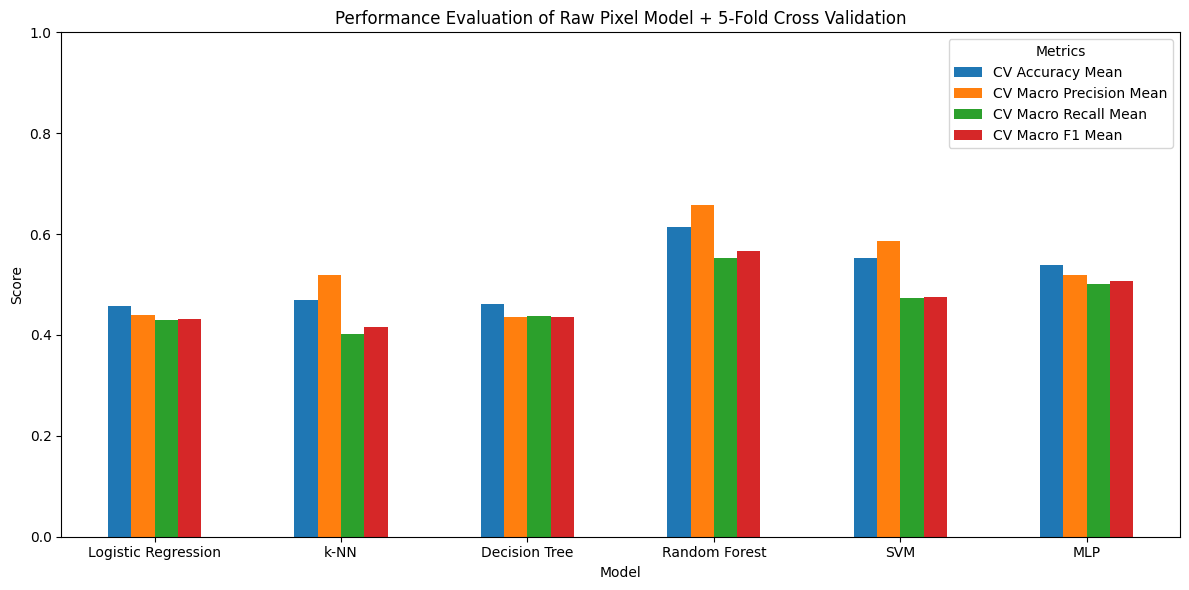

In [128]:
df_plot = df_raw_cv_results_rounded.copy()

eval_metrics = [
    'CV Accuracy Mean',
    'CV Macro Precision Mean',
    'CV Macro Recall Mean',
    'CV Macro F1 Mean'
]

df_plot = df_plot.set_index('Model')[eval_metrics]

ax = df_plot.plot(kind='bar', figsize=(12, 6))

plt.title('Performance Evaluation of Raw Pixel Model + 5-Fold Cross Validation')
plt.xlabel('Model')
plt.xticks(rotation=0)
plt.ylabel('Score')
plt.ylim(0, 1)
plt.legend(title='Metrics')
plt.tight_layout()
plt.show()